In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.")

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


In [2]:

# ── CELDA 2: Extracción SQL con creación de variable objetivo ──
# Variable objetivo: esta_humedo = 1 si humedad > 65%, 0 si humedad ≤ 65%
# El umbral del 65% se eligió basado en la mediana de humedad del dataset
SQL_QUERY = """
SELECT
    c.nombre                              AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.presion,
    r.velocidad_viento,
    r.fecha_extraccion,
    r.descripcion                         AS descripcion_clima,
    -- Variable objetivo: ¿El ambiente está húmedo?
    -- Umbral: 65% (mediana histórica de humedad en Colombia)
    CASE
        WHEN r.humedad > 65 THEN 1
        ELSE 0
    END                                   AS esta_humedo
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion;
"""

with engine.connect() as conn:
    df_clima = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_clima.shape[0]:,} filas × {df_clima.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_clima.columns.tolist()}")

print(f"\n⚖️ Balance de la variable objetivo (esta_húmedo):")
bal = df_clima['esta_humedo'].value_counts()
pct = df_clima['esta_humedo'].value_counts(normalize=True) * 100
print(f"   Húmedo (1 - humedad > 65%): {bal.get(1, 0):,}  ({pct.get(1, 0):.1f}%)")
print(f"   Seco   (0 - humedad ≤ 65%): {bal.get(0, 0):,}  ({pct.get(0, 0):.1f}%)")

print(f"\n📊 Estadísticas de humedad:")
print(f"   Media: {df_clima['humedad'].mean():.1f}%")
print(f"   Mediana: {df_clima['humedad'].median():.1f}%")
print(f"   Mínimo: {df_clima['humedad'].min():.1f}%")
print(f"   Máximo: {df_clima['humedad'].max():.1f}%")

print(f"\n🌆 Descripciones únicas de clima:")
print(df_clima['descripcion_clima'].value_counts().head(10))

df_clima.head()

✅ Datos cargados: 5,000 filas × 9 columnas

Columnas disponibles:
['ciudad', 'temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento', 'fecha_extraccion', 'descripcion_clima', 'esta_humedo']

⚖️ Balance de la variable objetivo (esta_húmedo):
   Húmedo (1 - humedad > 65%): 1,166  (23.3%)
   Seco   (0 - humedad ≤ 65%): 3,834  (76.7%)

📊 Estadísticas de humedad:
   Media: 50.5%
   Mediana: 47.0%
   Mínimo: 13.0%
   Máximo: 95.0%

🌆 Descripciones únicas de clima:
descripcion_clima
N/A    5000
Name: count, dtype: int64


,ciudad,temperatura,sensacion_termica,humedad,presion,velocidad_viento,fecha_extraccion,descripcion_clima,esta_humedo
0,Oklahoma,24.79,24.92,61,1020,5.83,2026-04-10 12:34:27.887472,N/A,0
1,Bismarck,20.52,20.19,60,1024,3.64,2026-04-10 12:34:27.887661,N/A,0
2,Tomah,7.92,5.48,52,1026,3.93,2026-04-10 12:34:27.887738,N/A,0
3,Taylor Springs,20.56,19.32,25,1015,3.26,2026-04-10 12:34:27.887799,N/A,0
4,Running Springs,10.51,9.26,63,1014,5.83,2026-04-10 12:34:27.887898,N/A,0


In [3]:
# ── CELDA 3: Validación y Exploración ─────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_clima.dtypes.to_frame('dtype').join(
    df_clima.isnull().sum().to_frame('nulos')
))

# Distribución por ciudad de la variable objetivo
print(f"\n🌍 Distribución de 'esta_humedo' por ciudad:")
city_stats = df_clima.groupby('ciudad')['esta_humedo'].agg(['mean', 'count'])
city_stats.columns = ['Proporción Húmedo', 'N registros']
city_stats['Proporción Húmedo'] = city_stats['Proporción Húmedo'] * 100
print(city_stats.sort_values('Proporción Húmedo', ascending=False))

plt.show()

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                            dtype  nulos
ciudad                     object      0
temperatura               float64      0
sensacion_termica         float64      0
humedad                     int64      0
presion                     int64      0
velocidad_viento          float64      0
fecha_extraccion   datetime64[ns]      0
descripcion_clima          object      0
esta_humedo                 int64      0

🌍 Distribución de 'esta_humedo' por ciudad:
             Proporción Húmedo  N registros
ciudad                                     
Winfield                 100.0            4
Algoma                   100.0            4
Allegan                  100.0            4
Allison                  100.0            1
Whitehall                100.0            1
...                        ...          ...
Laguna                     0.0            1
Lahoma                     0.0            1
Lake Butler                0.0            1
Lak

In [10]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_clima.copy()

# 4.1 Features de fecha
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['mes']        = df['fecha_extraccion'].dt.month
df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek  # 0=Lunes … 6=Domingo

# 4.2 Crear variable objetivo binaria a partir de humedad
# 1 = Húmedo, 0 = Seco
umbral_humedad = df['humedad'].median()
df['esta_humedo'] = np.where(df['humedad'] >= umbral_humedad, 1, 0)

# 4.3 Relleno de nulos con mediana en numéricas
num_cols = ['temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.4 One-Hot Encoding para ciudad
df = pd.get_dummies(df, columns=['ciudad'], drop_first=True, dtype=int)

# 4.5 Definir X e y — SIN escalado, porque CART no lo requiere
drop_cols = [
    'esta_humedo',
    'humedad',
    'fecha_extraccion',
    'descripcion_clima'
]

X_raw = df.drop(columns=drop_cols)
y = df['esta_humedo']

print("✅ Preprocesamiento completado")
print(f"   Shape X_raw: {X_raw.shape}")

print("\n📋 Columnas numéricas principales:")
print(['temperatura', 'sensacion_termica', 'presion', 'velocidad_viento', 'mes', 'dia_semana'])

print(f"\n🏙️ Variables creadas por ciudad: {sum(X_raw.columns.str.startswith('ciudad_'))}")

print(
    f"\n   Clases en y → "
    f"0 (Seco): {(y == 0).sum():,}  |  "
    f"1 (Húmedo): {(y == 1).sum():,}"
)

print(f"\n   Umbral usado para humedad: {umbral_humedad:.2f}")
print(f"   Balance: {(y == 1).mean() * 100:.1f}% es Húmedo")

print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")

✅ Preprocesamiento completado
   Shape X_raw: (5000, 1691)

📋 Columnas numéricas principales:
['temperatura', 'sensacion_termica', 'presion', 'velocidad_viento', 'mes', 'dia_semana']

🏙️ Variables creadas por ciudad: 1685

   Clases en y → 0 (Seco): 2,469  |  1 (Húmedo): 2,531

   Umbral usado para humedad: 47.00
   Balance: 50.6% es Húmedo

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


In [16]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      · criterion='gini'          — impureza Gini
      · class_weight='balanced'   — compensa posible desbalance
      · max_depth                 — None = árbol sin límite
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre': nombre,
        'train_size': len(X_train),
        'test_size': len(X_test),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'fpr': fpr,
        'tpr': tpr,
        'y_test': y_test,
        'y_pred': y_pred,
        'modelo': modelo
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [17]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_raw, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_raw, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_raw, y, test_size=0.30, nombre="Split 70/30"),
]

print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART':^65}")
print("=" * 65)

header = (
    f"{'Split':<12} {'N Train':>8} {'N Test':>8} "
    f"{'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
)

print(header)
print("-" * 65)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 65)

         MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART          
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     4,000    1,000  0.9110  0.9049  0.9209  0.9128  0.9769
Split 60/40     3,000    2,000  0.9030  0.9098  0.8972  0.9035  0.9598
Split 70/30     3,500    1,500  0.9127  0.9015  0.9289  0.9150  0.9722


🏆 Mejor max_depth según F1-Score: 15


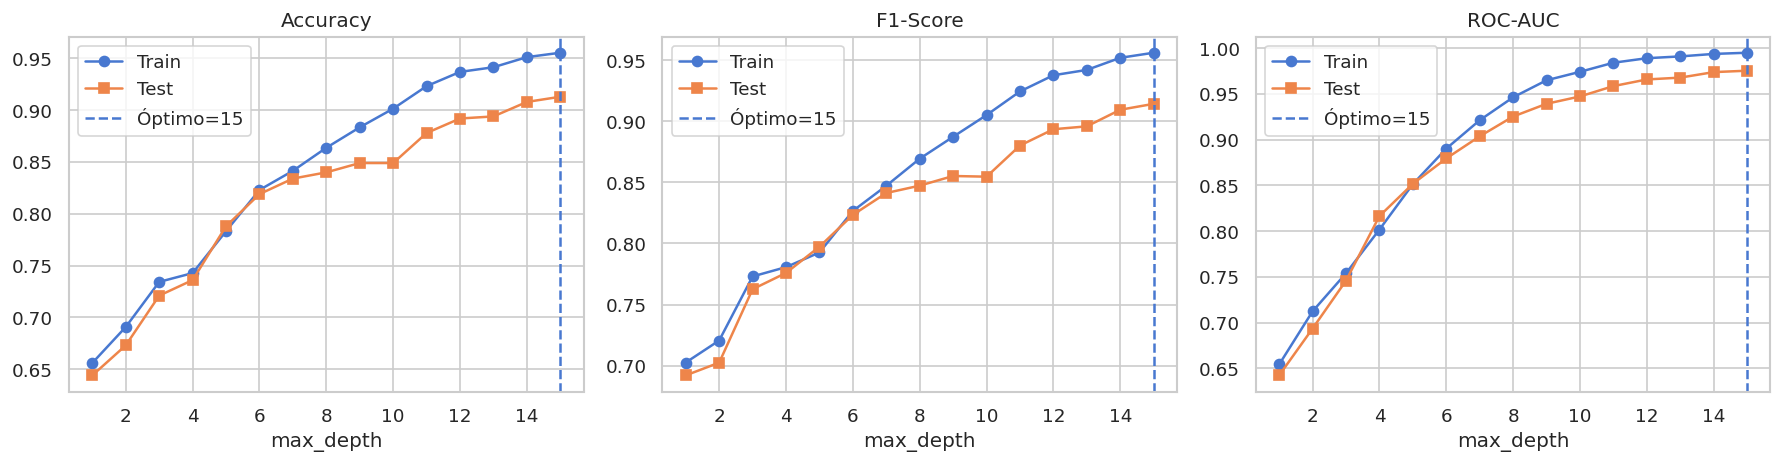

✅ Curvas de max_depth guardadas.


In [19]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

profundidades = range(1, 16)

acc_train = []
acc_test = []

f1_train = []
f1_test = []

auc_train = []
auc_test = []

for d in profundidades:

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    modelo.fit(X_tr, y_tr)

    # Predicciones TRAIN
    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    # Predicciones TEST
    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    # Accuracy
    acc_train.append(
        accuracy_score(y_tr, pred_train)
    )

    acc_test.append(
        accuracy_score(y_te, pred_test)
    )

    # F1
    f1_train.append(
        f1_score(y_tr, pred_train, zero_division=0)
    )

    f1_test.append(
        f1_score(y_te, pred_test, zero_division=0)
    )

    # ROC-AUC
    auc_train.append(
        roc_auc_score(y_tr, prob_train)
    )

    auc_test.append(
        roc_auc_score(y_te, prob_test)
    )

# Mejor profundidad según F1
mejor_depth = list(profundidades)[
    int(np.argmax(f1_test))
]

print(f"🏆 Mejor max_depth según F1-Score: {mejor_depth}")

# ── Gráficas ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(
    profundidades,
    acc_train,
    'o-',
    label='Train'
)

axes[0].plot(
    profundidades,
    acc_test,
    's-',
    label='Test'
)

axes[0].axvline(
    x=mejor_depth,
    linestyle='--',
    label=f'Óptimo={mejor_depth}'
)

axes[0].set_title('Accuracy')
axes[0].set_xlabel('max_depth')
axes[0].legend()

# F1
axes[1].plot(
    profundidades,
    f1_train,
    'o-',
    label='Train'
)

axes[1].plot(
    profundidades,
    f1_test,
    's-',
    label='Test'
)

axes[1].axvline(
    x=mejor_depth,
    linestyle='--',
    label=f'Óptimo={mejor_depth}'
)

axes[1].set_title('F1-Score')
axes[1].set_xlabel('max_depth')
axes[1].legend()

# ROC-AUC
axes[2].plot(
    profundidades,
    auc_train,
    'o-',
    label='Train'
)

axes[2].plot(
    profundidades,
    auc_test,
    's-',
    label='Test'
)

axes[2].axvline(
    x=mejor_depth,
    linestyle='--',
    label=f'Óptimo={mejor_depth}'
)

axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('max_depth')
axes[2].legend()

plt.tight_layout()

plt.savefig(
    '../data/graficas/max_depth_cart.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas de max_depth guardadas.")

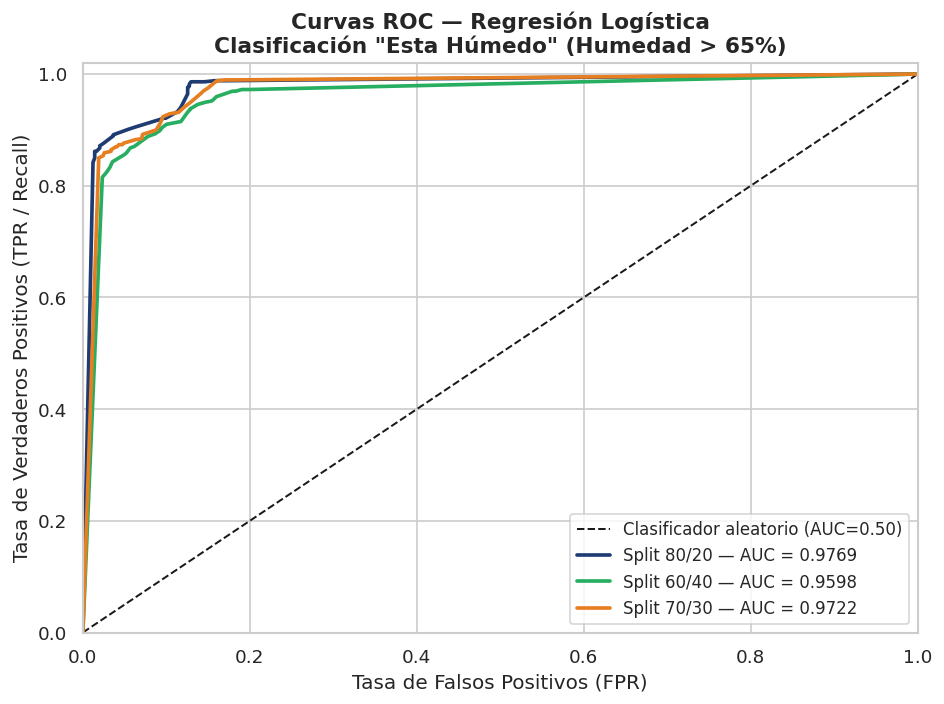

✅ Curvas ROC guardadas en data/graficas/roc_humedad_logistic.png


In [20]:
# ── CELDA 8: Curvas ROC comparativas ──────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística\nClasificación "Esta Húmedo" (Humedad > 65%)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_humedad_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas ROC guardadas en data/graficas/roc_humedad_logistic.png")

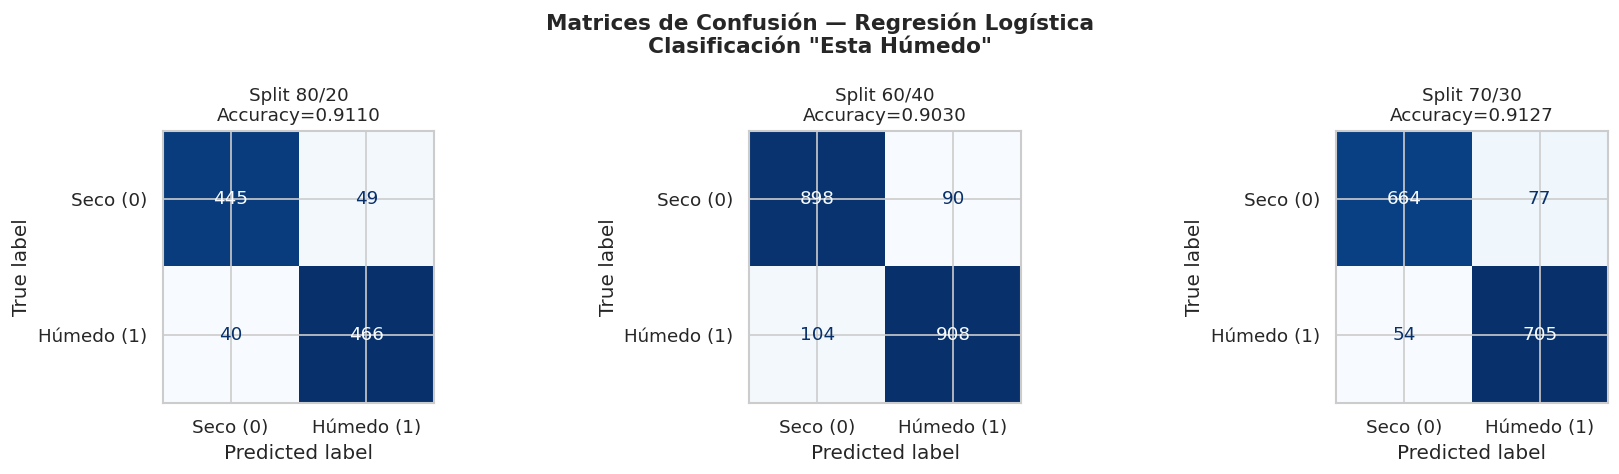

✅ Matrices de confusión guardadas en data/graficas/confusion_humedad_logistic.png


In [21]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística\nClasificación "Esta Húmedo"', 
             fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Seco (0)', 'Húmedo (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_humedad_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusión guardadas en data/graficas/confusion_humedad_logistic.png")

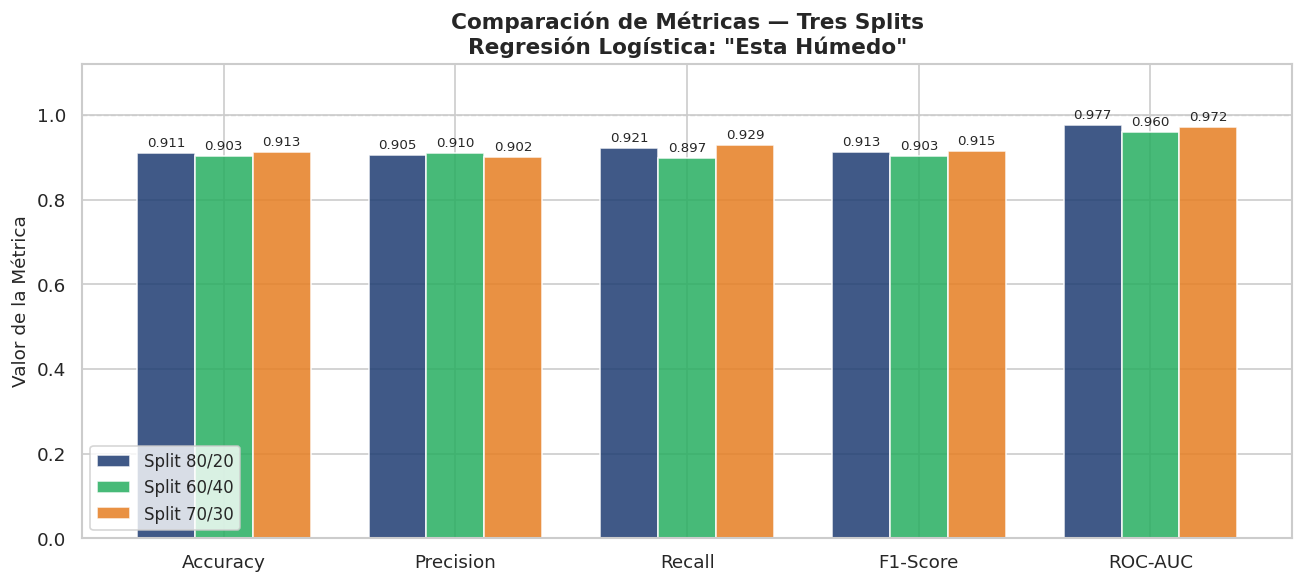

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_humedad_logistic.png


In [22]:
# ── CELDA 10: Gráfico comparativo de métricas ─────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística: "Esta Húmedo"', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_humedad_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_humedad_logistic.png")

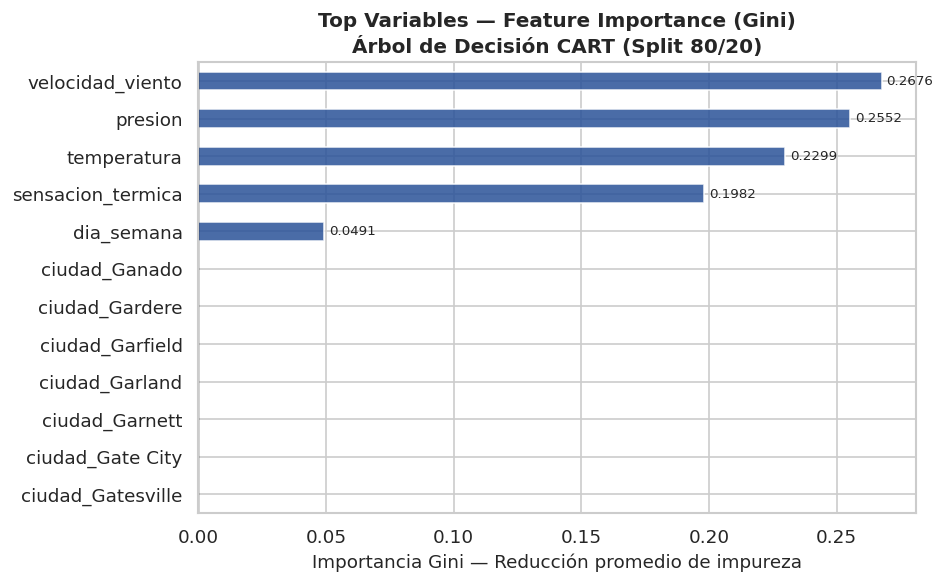

✅ Feature importance guardada en data/graficas/feature_importance_cart_humedad.png

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes:
velocidad_viento     0.267629
presion              0.255187
temperatura          0.229929
sensacion_termica    0.198176
dia_semana           0.049080


In [27]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────

# Modelo de referencia → Split 80/20
modelo_ref = resultados[0]['modelo']

# Importancia de variables
importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=X_raw.columns
)

# Mostrar solo las 12 variables más importantes
importancias_ord = importancias.sort_values(ascending=True).tail(12)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

importancias_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel(
    'Importancia Gini — Reducción promedio de impureza',
    fontsize=11
)

ax.set_title(
    'Top Variables — Feature Importance (Gini)\nÁrbol de Decisión CART (Split 80/20)',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(
    x=0,
    color='black',
    linewidth=0.8
)

# Anotar valores
for patch in ax.patches:
    width = patch.get_width()

    if width > 0.001:
        ax.text(
            width + 0.002,
            patch.get_y() + patch.get_height() / 2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    '../data/graficas/feature_importance_cart_humedad.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Feature importance guardada en data/graficas/feature_importance_cart_humedad.png")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")

print("\nTop 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())

In [28]:
# ── CELDA 12: DataFrame resumen de métricas ───────────────────
resumen = pd.DataFrame([{
    'Split'             : r['nombre'],
    'N Entrenamiento'   : r['train_size'],
    'N Prueba'          : r['test_size'],
    'Accuracy'          : round(r['accuracy'], 4),
    'Precision'         : round(r['precision'], 4),
    'Recall'            : round(r['recall'], 4),
    'F1-Score'          : round(r['f1'], 4),
    'ROC-AUC'           : round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("\n" + "=" * 70)
print(f"{'TABLA FINAL DE MÉTRICAS — Regresión Logística Binaria':^70}")
print(f"{'Clasificación: "Esta Húmedo" (Humedad > 65%)':^70}")
print("=" * 70)
display(resumen.style
    .background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Regresión Logística — Predicción de Ambiente Húmedo (humedad > 65%)")
)

print(f"\n📊 Promedio de métricas entre splits:")
print(f"   Accuracy promedio: {resumen['Accuracy'].mean():.4f}")
print(f"   F1-Score promedio: {resumen['F1-Score'].mean():.4f}")
print(f"   ROC-AUC promedio:  {resumen['ROC-AUC'].mean():.4f}")


        TABLA FINAL DE MÉTRICAS — Regresión Logística Binaria         
             Clasificación: "Esta Húmedo" (Humedad > 65%)             


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,4000,1000,0.9110,0.9049,0.9209,0.9128,0.9769
Split 60/40,3000,2000,0.9030,0.9098,0.8972,0.9035,0.9598
Split 70/30,3500,1500,0.9127,0.9015,0.9289,0.9150,0.9722



📊 Promedio de métricas entre splits:
   Accuracy promedio: 0.9089
   F1-Score promedio: 0.9104
   ROC-AUC promedio:  0.9696
